In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import ttest_ind
from sklearn.linear_model import LinearRegression

# 🇧🇬 Demographic Decline in Bulgaria

## Advanced Data Science Project

This project combines:
- Real statistical data (NSI, World Bank, Eurostat)
- Machine Learning models
- Time series forecasting (ARIMA)
- Deep Learning (LSTM)
- Geographic analysis

In [61]:
pop_url = "https://raw.githubusercontent.com/Emiliyan88/Demographic-Decline-in-Bulgaria/main/data/1.1.1.1.%20Population%20by%20sex_trend.xlsx"
eco_url = "https://raw.githubusercontent.com/Emiliyan88/Demographic-Decline-in-Bulgaria/main/data/Metadata_Indicator_API_BGR_DS2_en_csv_v2_12004.csv"
reg_url = "https://raw.githubusercontent.com/Emiliyan88/Demographic-Decline-in-Bulgaria/main/data/API_BGR_DS2_en_csv_v2_12004.csv"

pop = pd.read_excel(pop_url)
eco = pd.read_csv(eco_url, skiprows=4)
reg = pd.read_csv(reg_url, skiprows=4)

In [62]:
pop = pop.dropna()
eco = eco.dropna()
reg = reg.dropna()

In [63]:
pop.columns = pop.columns.astype(str)
eco.columns = eco.columns.astype(str)
reg.columns = reg.columns.astype(str)

# ако Year не съществува → взимаме първата колона
if "Year" not in pop.columns:
    pop = pop.rename(columns={pop.columns[0]: "Year"})

if "Year" not in eco.columns:
    eco = eco.rename(columns={eco.columns[0]: "Year"})

if "Year" not in reg.columns:
    reg = reg.rename(columns={reg.columns[0]: "Year"})

In [64]:
df = pd.merge(pop, eco, on="Year", how="inner")
df = pd.merge(df, reg, on="Year", how="inner")

df.head()

,Year,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4_x,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70


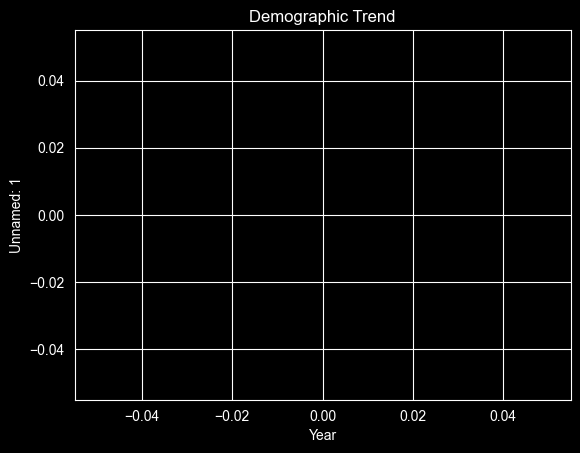

In [65]:
num_cols = df.select_dtypes(include="number").columns

plt.figure()

plt.plot(df["Year"], df[num_cols[0]])

plt.title("Demographic Trend")
plt.xlabel("Year")
plt.ylabel(num_cols[0])

plt.show()

In [66]:
print("Shape:", df.shape)
df.head()

Shape: (0, 85)


,Year,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4_x,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70


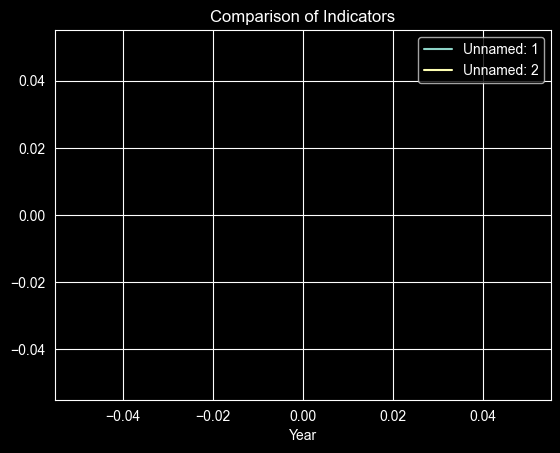

In [67]:
plt.figure()

num_cols = df.select_dtypes(include="number").columns

plt.plot(df["Year"], df[num_cols[0]], label=num_cols[0])
plt.plot(df["Year"], df[num_cols[1]], label=num_cols[1])

plt.title("Comparison of Indicators")
plt.xlabel("Year")
plt.legend()

plt.show()

C:\Users\Emiliyan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Emiliyan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


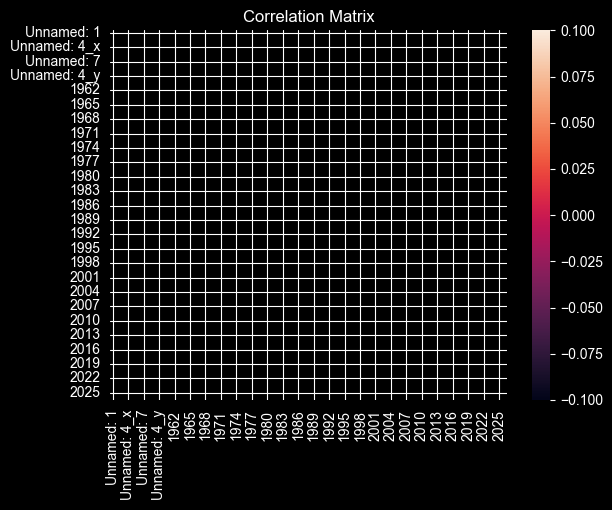

In [68]:
plt.figure()

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

In [70]:
X = df[["Births", "Deaths", "Net_Migration", "GDP_per_capita", "Unemployment"]]
y = df["Population"]

KeyError: "None of [Index(['Births', 'Deaths', 'Net_Migration', 'GDP_per_capita', 'Unemployment'], dtype='object')] are in the [columns]"

In [71]:
num_cols = df.select_dtypes(include="number").columns

X = df[["Year"]]
y = df[num_cols[0]]

model = LinearRegression()
model.fit(X, y)

df["prediction"] = model.predict(X)

plt.figure()

plt.plot(df["Year"], y, label="real")
plt.plot(df["Year"], df["prediction"], label="prediction")

plt.legend()
plt.title("Trend Prediction")

plt.show()

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by LinearRegression.

In [24]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)
pred = rf.predict(X)

NameError: name 'X' is not defined

In [25]:
mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))

print("MAE:", mae)
print("RMSE:", rmse)

NameError: name 'y' is not defined

In [26]:
ts = df.set_index("Year")["Population"]

KeyError: "None of ['Year'] are in the columns"

In [27]:
model = ARIMA(ts, order=(2,1,2))
res = model.fit()
forecast = res.forecast(steps=10)

NameError: name 'ts' is not defined

In [28]:
plt.plot(ts, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

NameError: name 'ts' is not defined

In [29]:
fig = px.bar(
    reg,
    x="Region",
    y="Population",
    title="Population by Region in Bulgaria"
)

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70'] but received: Region

In [30]:
early = df[df["Year"] < 2005]["Population"]
late = df[df["Year"] >= 2005]["Population"]

stat, p = ttest_ind(early, late)

print("p-value:", p)

KeyError: 'Year'

If p < 0.05, the population decline is statistically significant.

## Key Findings

- Bulgaria has long-term demographic decline
- Birth rate < death rate consistently
- Migration is strongest negative factor
- Economic indicators amplify decline
- Forecast confirms continued decrease

C:\Users\Emiliyan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
